# Titanic Data Clean
---
Cleaning the Titanic data source file from Seeborn

Import modules:

In [19]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Import the Titanic data:

In [20]:
# Load Titanic dataset
titanic_df = sns.load_dataset("titanic")

View the top 10 lines of the data:

In [21]:
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Check summary of data before clean:

In [22]:
before_summary = pd.DataFrame({
    "dtype": titanic_df.dtypes,
    "missing_values": titanic_df.isnull().sum(),
    "non_missing": titanic_df.notnull().sum(),
    "unique_values": titanic_df.nunique()
})
before_summary

,dtype,missing_values,non_missing,unique_values
survived,int64,0,891,2
pclass,int64,0,891,3
sex,object,0,891,2
age,float64,177,714,88
sibsp,int64,0,891,7
parch,int64,0,891,7
fare,float64,0,891,248
embarked,object,2,889,3
class,category,0,891,3
who,object,0,891,3


Create a copy of the data for cleaning:

In [23]:
titanic = titanic_df.copy()

Drop deck column as it is missing too many values:

In [24]:
titanic = titanic.drop(columns=['deck'])

Fill missing ages with median:

In [25]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

Fill missing embarked with the most common value:

In [26]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

embark_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
titanic['embark_town'] = titanic['embark_town'].fillna(
    titanic['embarked'].map(embark_map)
)

Remove duplicates:

In [27]:
titanic = titanic.drop_duplicates()

Set columns to catagorical:

In [28]:
categorical_cols = ['sex', 'class', 'embarked', 'who', 'adult_male', 'alone']
for col in categorical_cols:
    titanic[col] = titanic[col].astype('category')

Create an age group column, with these boundaries:
- `>= 0  < 18` - child
- `>= 18 < 65` - Adult
- `>= 65 < 100` - Senior

In [29]:
titanic['age_group'] = pd.cut(
    titanic['age'],
    bins=[0, 18, 65, 100],
    labels=['Child', 'Adult', 'Senior'],
    include_lowest=True
)

Create after cleaning summary:

In [30]:
after_summary = pd.DataFrame({
    "dtype": titanic.dtypes,
    "missing_values": titanic.isnull().sum(),
    "non_missing": titanic.notnull().sum(),
    "unique_values": titanic.nunique()
})

View before summary again:

In [31]:
before_summary

,dtype,missing_values,non_missing,unique_values
survived,int64,0,891,2
pclass,int64,0,891,3
sex,object,0,891,2
age,float64,177,714,88
sibsp,int64,0,891,7
parch,int64,0,891,7
fare,float64,0,891,248
embarked,object,2,889,3
class,category,0,891,3
who,object,0,891,3


View after cleaning summary:

In [32]:
after_summary

,dtype,missing_values,non_missing,unique_values
survived,int64,0,775,2
pclass,int64,0,775,3
sex,category,0,775,2
age,float64,0,775,88
sibsp,int64,0,775,7
parch,int64,0,775,7
fare,float64,0,775,248
embarked,category,0,775,3
class,category,0,775,3
who,category,0,775,3


View first 10 rows of the clean data:

In [33]:
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adult
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,Adult
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,Adult
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False,Child
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,Adult
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,Child


Add a numeric version of age_group to use in correlation:

In [34]:
titanic['age_group_num'] = titanic['age_group'].cat.codes

Do a correlation of numeric fields:

In [35]:
numeric_cols = titanic.select_dtypes(include=['int8', 'int64', 'float64'])
corr_matrix = numeric_cols.corr()
corr_matrix

,survived,pclass,age,sibsp,parch,fare,age_group_num
survived,1.000000,-0.331388,-0.078114,-0.037841,0.069864,0.247159,-0.102707
pclass,-0.331388,1.000000,-0.342745,0.087050,0.038998,-0.554649,-0.174099
age,-0.078114,-0.342745,1.000000,-0.279316,-0.182697,0.092503,0.683207
sibsp,-0.037841,0.087050,-0.279316,1.000000,0.379535,0.133807,-0.344153
parch,0.069864,0.038998,-0.182697,0.379535,1.000000,0.190823,-0.288506
fare,0.247159,-0.554649,0.092503,0.133807,0.190823,1.000000,0.011275
age_group_num,-0.102707,-0.174099,0.683207,-0.344153,-0.288506,0.011275,1.000000


Display a heatmap chart:

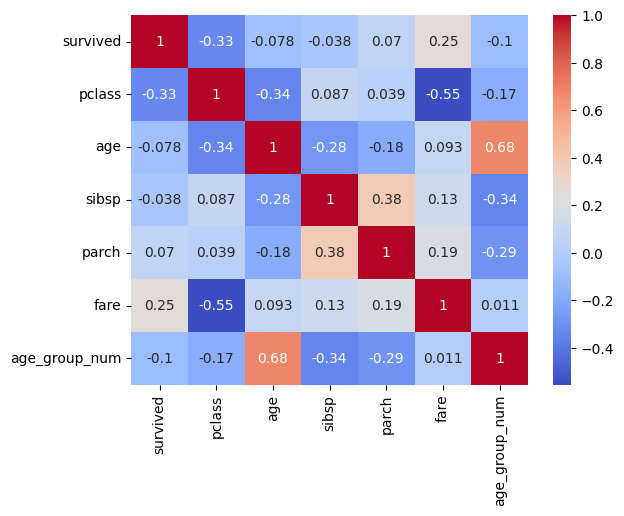

In [36]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Heatmap above shows correlation between survived and class and survived and fare. 

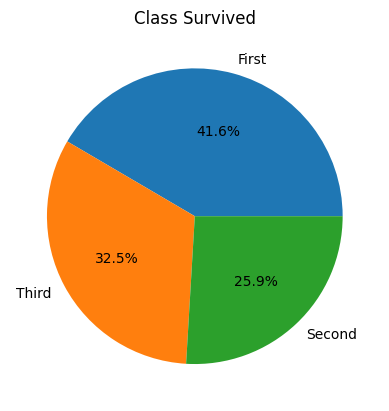

In [37]:
# Filter only survived passengers
survived_df = titanic[titanic['survived'] == 1]

# Count survivors by class
class_counts = survived_df['class'].value_counts()

# Plot pie chart
class_counts.plot(
    kind='pie', 
    autopct="%.1f%%", 
    title="Class Survived"
)
plt.ylabel("")
plt.show()

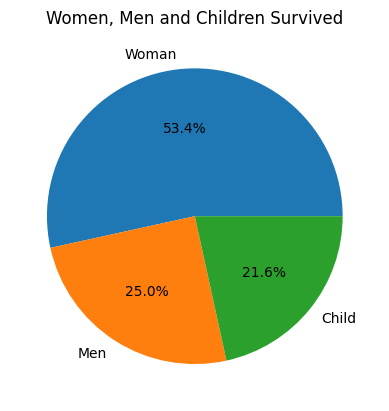

In [48]:
# Filter survivors
survivors = titanic[titanic['survived'] == 1].copy()

# Define Women, Men and Children group
survivors['group'] = survivors.apply(
    lambda row: 'Child' if row['age_group'] == 'Child' else ('Woman' if row['sex'] == 'female' else 'Men'),
    axis=1
)

counts = survivors['group'].value_counts()

# Plot pie chart
counts.plot(
    kind='pie',
    autopct="%.1f%%",
    title="Women, Men and Children Survived",
    ylabel="" 
)
plt.show()